In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import gc, numpy as np, pandas as pd
from pathlib import Path
from sklearn.preprocessing import StandardScaler
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

In [4]:
caminho_arquivo = "/content/drive/MyDrive/Projeto Aplicado 4/dataset (2).csv"
df = pd.read_csv(caminho_arquivo)

In [5]:
print(df.head())

   NU_ANO_CENSO  CO_IES  Modalidade  Rede  CO_REGIAO  CO_UF  CO_MUNICIPIO  \
0          2014     699           0     0          1     11       1100023   
1          2014     699           0     0          1     11       1100023   
2          2014     833           0     1          1     11       1100023   
3          2014     833           0     1          1     11       1100023   
4          2014     833           0     1          1     11       1100023   

   TP_REDE  TP_MODALIDADE_ENSINO  QT_ING  ...  QT_ING_60_MAIS  QT_MAT  \
0      1.0                     1      40  ...               0      78   
1      1.0                     1      52  ...               0     186   
2      2.0                     1       9  ...               0      47   
3      2.0                     1       4  ...               0      31   
4      2.0                     1      49  ...               0     240   

   QT_SIT_TRANCADA  QT_SIT_DESVINCULADO  QT_SIT_TRANSFERIDO  QT_SIT_FALECIDO  \
0                1

In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3557875 entries, 0 to 3557874
Data columns (total 28 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   NU_ANO_CENSO           int64  
 1   CO_IES                 int64  
 2   Modalidade             int64  
 3   Rede                   int64  
 4   CO_REGIAO              int64  
 5   CO_UF                  int64  
 6   CO_MUNICIPIO           int64  
 7   TP_REDE                float64
 8   TP_MODALIDADE_ENSINO   int64  
 9   QT_ING                 int64  
 10  QT_ING_FEM             int64  
 11  QT_ING_MASC            int64  
 12  QT_ING_18_24           int64  
 13  QT_ING_25_29           int64  
 14  QT_ING_30_34           int64  
 15  QT_ING_35_39           int64  
 16  QT_ING_40_49           int64  
 17  QT_ING_50_59           int64  
 18  QT_ING_60_MAIS         int64  
 19  QT_MAT                 int64  
 20  QT_SIT_TRANCADA        int64  
 21  QT_SIT_DESVINCULADO    int64  
 22  QT_SIT_TRANSFERIDO

In [7]:
print(df.describe(include="all"))

        NU_ANO_CENSO        CO_IES    Modalidade          Rede     CO_REGIAO  \
count   3.557875e+06  3.557875e+06  3.557875e+06  3.557875e+06  3.557875e+06   
unique           NaN           NaN           NaN           NaN           NaN   
top              NaN           NaN           NaN           NaN           NaN   
freq             NaN           NaN           NaN           NaN           NaN   
mean    2.021206e+03  1.528033e+03  8.930027e-01  9.494285e-01  2.979202e+00   
std     2.562372e+00  2.738231e+03  3.091099e-01  2.191210e-01  1.166612e+00   
min     2.014000e+03  1.000000e+00  0.000000e+00  0.000000e+00 -1.000000e+00   
25%     2.020000e+03  3.220000e+02  1.000000e+00  1.000000e+00  2.000000e+00   
50%     2.022000e+03  1.196000e+03  1.000000e+00  1.000000e+00  3.000000e+00   
75%     2.023000e+03  1.491000e+03  1.000000e+00  1.000000e+00  4.000000e+00   
max     2.024000e+03  2.992900e+04  1.000000e+00  1.000000e+00  5.000000e+00   

               CO_UF  CO_MUNICIPIO     

In [8]:
print("Shape:", df.shape)   # (linhas, colunas)
print("Total de linhas:", len(df))
print("Total de colunas:", df.shape[1])

Shape: (3557875, 28)
Total de linhas: 3557875
Total de colunas: 28


In [9]:
# Leitura do arquivo CSV
df = pd.read_csv(caminho_arquivo, sep=',', low_memory=False)
display(df.head(-16))

,NU_ANO_CENSO,CO_IES,Modalidade,Rede,CO_REGIAO,CO_UF,CO_MUNICIPIO,TP_REDE,TP_MODALIDADE_ENSINO,QT_ING,...,QT_ING_60_MAIS,QT_MAT,QT_SIT_TRANCADA,QT_SIT_DESVINCULADO,QT_SIT_TRANSFERIDO,QT_SIT_FALECIDO,QT_ING_PROCESCPUBLICA,QT_ING_PROCESCPRIVADA,CO_CINE_ROTULO_id,NO_CINE_ROTULO
0,2014,699,0,0,1,11,1100023,1.0,1,40,...,0,78,1,5,0,0,40,0,92,Engenharia de alimentos
1,2014,699,0,0,1,11,1100023,1.0,1,52,...,0,186,1,17,0,0,49,3,224,Pedagogia
2,2014,833,0,1,1,11,1100023,2.0,1,9,...,0,47,82,49,0,1,8,1,198,Administração
3,2014,833,0,1,1,11,1100023,2.0,1,4,...,0,31,32,17,0,0,3,1,4,Biologia formação de professor
4,2014,833,0,1,1,11,1100023,2.0,1,49,...,0,240,135,114,0,0,44,5,11,Contabilidade
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3557854,2024,3649,1,1,4,42,4219705,2.0,2,1,...,0,1,0,0,0,0,1,0,127,Programas interdisciplinares abrangendo educação
3557855,2024,3649,1,1,4,42,4219705,2.0,2,1,...,0,0,0,1,0,0,1,0,165,Psicopedagogia
3557856,2024,3649,1,1,4,42,4219705,2.0,2,1,...,0,1,0,0,0,0,1,0,255,Publicidade e propaganda
3557857,2024,3649,1,1,4,42,4219705,2.0,2,0,...,0,0,0,1,0,0,0,0,99,Química formação de professor


In [10]:
df = pd.read_csv(caminho_arquivo, low_memory=False)

# garantir que NU_ANO_CENSO esteja numérico
df["NU_ANO_CENSO"] = pd.to_numeric(df["NU_ANO_CENSO"], errors="coerce")

# Máscaras por intervalo de anos

mask_train = (df["NU_ANO_CENSO"] >= 2014) & (df["NU_ANO_CENSO"] <= 2020)
mask_val   = (df["NU_ANO_CENSO"] >= 2021) & (df["NU_ANO_CENSO"] <= 2022)
mask_test  = (df["NU_ANO_CENSO"] >= 2023) & (df["NU_ANO_CENSO"] <= 2024)

df_train = df.loc[mask_train].copy()
df_val   = df.loc[mask_val].copy()
df_test  = df.loc[mask_test].copy()

# Relatórios rápidos

def resumo(split_name, dfx):
    anos = sorted(dfx["NU_ANO_CENSO"].dropna().unique().tolist())
    print(f"{split_name}: {dfx.shape} | anos: {anos if anos else '—'}")

print("Divisão temporal solicitada:")
resumo("Treino (2014–2020)", df_train)
resumo("Validação (2021–2022)", df_val)
resumo("Teste (2023–2024)", df_test)

# alertas úteis, caso falte algum intervalo no seu arquivo atual
if df_train.empty:
    print(" Aviso: nenhum registro entre 2014–2020.")
if df_val.empty:
    print(" Aviso: nenhum registro entre 2021–2022.")
if df_test.empty:
    print(" Aviso: nenhum registro entre 2023–2024.")

Divisão temporal solicitada:
Treino (2014–2020): (1148111, 28) | anos: [2014, 2015, 2016, 2017, 2018, 2019, 2020]
Validação (2021–2022): (1017805, 28) | anos: [2021, 2022]
Teste (2023–2024): (1391959, 28) | anos: [2023, 2024]


In [11]:
# Salvar arquivos
base_out = Path("/content/drive/MyDrive/Projeto Aplicado 4")
base_out.mkdir(parents=True, exist_ok=True)

path_train = base_out / "dataset_train_2014_2020.csv"
path_val   = base_out / "dataset_val_2021_2022.csv"
path_test  = base_out / "dataset_test_2023_2024.csv"

df_train.to_csv(path_train, index=False)
df_val.to_csv(path_val, index=False)
df_test.to_csv(path_test, index=False)

print(" Arquivos salvos:")
print(" -", path_train)
print(" -", path_val)
print(" -", path_test)

 Arquivos salvos:
 - /content/drive/MyDrive/Projeto Aplicado 4/dataset_train_2014_2020.csv
 - /content/drive/MyDrive/Projeto Aplicado 4/dataset_val_2021_2022.csv
 - /content/drive/MyDrive/Projeto Aplicado 4/dataset_test_2023_2024.csv


In [12]:
# Carregar o dataset de treino
caminho_treino = "/content/drive/MyDrive/Projeto Aplicado 4/dataset_train_2014_2020.csv"
df_train = pd.read_csv(caminho_treino, low_memory=False)

In [13]:
# Garantir que as colunas necessárias existam
required_cols = [
    "NU_ANO_CENSO", "Modalidade", "QT_SIT_TRANCADA", "QT_SIT_DESVINCULADO",
    "QT_SIT_TRANSFERIDO", "QT_SIT_FALECIDO", "QT_MAT"
]
missing = [c for c in required_cols if c not in df_train.columns]
if missing:
    raise ValueError(f"Colunas ausentes no dataset de treino: {missing}")

# Criar a métrica de evasão total por linha
df_train["QT_EVASAO_TOTAL"] = (
    df_train["QT_SIT_TRANCADA"].fillna(0) +
    df_train["QT_SIT_DESVINCULADO"].fillna(0) +
    df_train["QT_SIT_TRANSFERIDO"].fillna(0) +
    df_train["QT_SIT_FALECIDO"].fillna(0)
)

# Remover linhas com QT_MAT <= 0 para evitar divisão por zero
df_train = df_train[df_train["QT_MAT"] > 0].copy()

# Agregar por Ano e Modalidade (taxa = soma(evasão) / soma(matrículas))
agg = (
    df_train
    .groupby(["NU_ANO_CENSO", "Modalidade"], as_index=False)
    .agg(QT_EVASAO_TOTAL=("QT_EVASAO_TOTAL", "sum"),
         QT_MAT=("QT_MAT", "sum"))
)
agg["TAXA_EVASAO"] = agg["QT_EVASAO_TOTAL"] / agg["QT_MAT"]

# Pivot para ter duas séries: Presencial (0) e EAD (1)
pivot = agg.pivot(index="NU_ANO_CENSO", columns="Modalidade", values="TAXA_EVASAO").sort_index()

In [14]:
# Pivot para ter duas séries: Presencial (0) e EAD (1)
pivot = agg.pivot(index="NU_ANO_CENSO", columns="Modalidade", values="TAXA_EVASAO").sort_index()

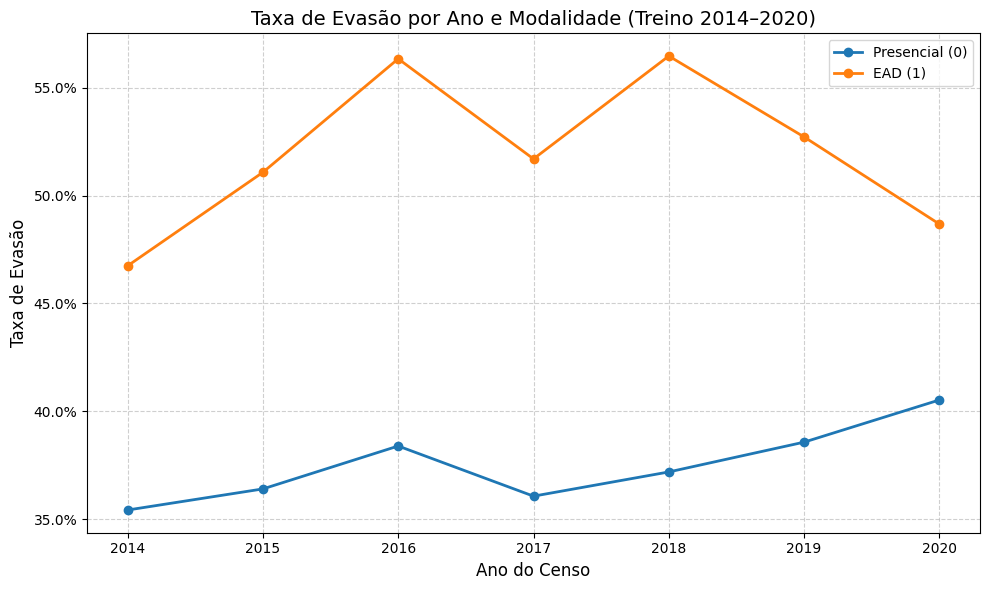

In [15]:
# Plot
plt.figure(figsize=(10,6))
if 0 in pivot.columns:
    plt.plot(pivot.index, pivot[0].values, marker="o", linewidth=2, label="Presencial (0)")
if 1 in pivot.columns:
    plt.plot(pivot.index, pivot[1].values, marker="o", linewidth=2, label="EAD (1)")

plt.title("Taxa de Evasão por Ano e Modalidade (Treino 2014–2020)", fontsize=14)
plt.xlabel("Ano do Censo", fontsize=12)
plt.ylabel("Taxa de Evasão", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()

# Eixo Y em porcentagem
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x*100:.1f}%"))
plt.tight_layout()
plt.show()


In [17]:
# Carregar o dataset de treino
caminho_val = "/content/drive/MyDrive/Projeto Aplicado 4/dataset_val_2021_2022.csv"
df_train = pd.read_csv(caminho_val, low_memory=False)
# Garantir que as colunas necessárias existam
required_cols = [
    "NU_ANO_CENSO", "Modalidade", "QT_SIT_TRANCADA", "QT_SIT_DESVINCULADO",
    "QT_SIT_TRANSFERIDO", "QT_SIT_FALECIDO", "QT_MAT"
]
missing = [c for c in required_cols if c not in df_train.columns]
if missing:
    raise ValueError(f"Colunas ausentes no dataset de treino: {missing}")

# Criar a métrica de evasão total por linha
df_train["QT_EVASAO_TOTAL"] = (
    df_train["QT_SIT_TRANCADA"].fillna(0) +
    df_train["QT_SIT_DESVINCULADO"].fillna(0) +
    df_train["QT_SIT_TRANSFERIDO"].fillna(0) +
    df_train["QT_SIT_FALECIDO"].fillna(0)
)

# Remover linhas com QT_MAT <= 0 para evitar divisão por zero
df_train = df_train[df_train["QT_MAT"] > 0].copy()

# Agregar por Ano e Modalidade (taxa = soma(evasão) / soma(matrículas))
agg = (
    df_train
    .groupby(["NU_ANO_CENSO", "Modalidade"], as_index=False)
    .agg(QT_EVASAO_TOTAL=("QT_EVASAO_TOTAL", "sum"),
         QT_MAT=("QT_MAT", "sum"))
)
agg["TAXA_EVASAO"] = agg["QT_EVASAO_TOTAL"] / agg["QT_MAT"]

# Pivot para ter duas séries: Presencial (0) e EAD (1)
pivot = agg.pivot(index="NU_ANO_CENSO", columns="Modalidade", values="TAXA_EVASAO").sort_index()

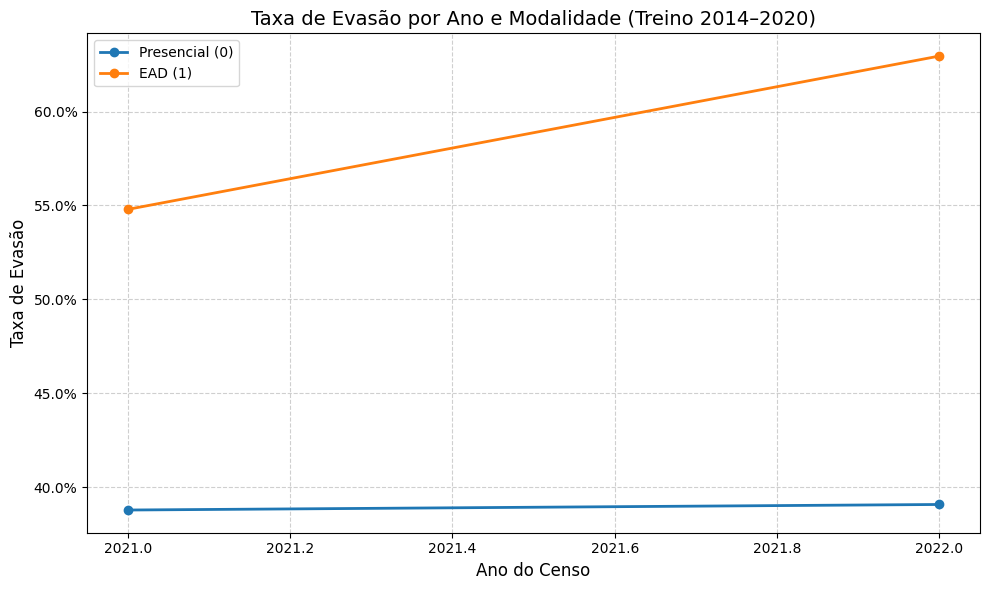

In [22]:
# Plot
plt.figure(figsize=(10,6))
if 0 in pivot.columns:
    plt.plot(pivot.index, pivot[0].values, marker="o", linewidth=2, label="Presencial (0)")
if 1 in pivot.columns:
    plt.plot(pivot.index, pivot[1].values, marker="o", linewidth=2, label="EAD (1)")

plt.title("Taxa de Evasão por Ano e Modalidade (Treino 2014–2020)", fontsize=14)
plt.xlabel("Ano do Censo", fontsize=12)
plt.ylabel("Taxa de Evasão", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()

# Eixo Y em porcentagem
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x*100:.1f}%"))
plt.tight_layout()
plt.show()